In [1]:

import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from torch.optim import Adam
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ==================== CONFIGURATION ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths
train_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images'#a1#'/home/iiitdmk-param/Desktop/Meher/Data/strong_images'
train_mask_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_1cmasks'#a2# '/home/iiitdmk-param/Desktop/Meher/Data/strong_labels' 
val_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images'#'/home/iiitdmk-param/Desktop/Meher/Data/weak_images'
val_mask_dir =  '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_1cmasks' #a2#'/home/iiitdmk-param/Desktop/Meher/Data/weak_labels'
sam_checkpoint = "/home/iiitdmk-param/Desktop/Research/3/Data/sam_vit_b.pth"
model_type = "vit_b"

# Training parameters
BATCH_SIZE = 4
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
NUM_CLASSES = 18

# ==================== CLASS INFORMATION ====================
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

# ==================== SIMPLE DATA TRANSFORM ====================
class SimpleTransform:
    def __call__(self, image, mask):
        # Resize to 256x256 and normalize
        image = cv2.resize(image, (256, 256))
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        
        # Normalize image
        image = image.astype(np.float32) / 255.0
        image = (image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
        
        # Convert to tensor
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).long()  # Ensure long type
        
        return image, mask

# ==================== MODEL ARCHITECTURE ====================
class HighIoUSAMWrapper(nn.Module):
    def __init__(self, sam_model, num_classes):
        super().__init__()
        self.sam = sam_model
        self.num_classes = num_classes
        
        # Simple segmentation head
        self.segmentation_head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )
        
        # Freeze SAM encoder
        for param in self.sam.image_encoder.parameters():
            param.requires_grad = False
    
    def unfreeze_encoder(self, percentage=0.5):
        total_layers = len(list(self.sam.image_encoder.parameters()))
        layers_to_unfreeze = int(total_layers * percentage)
        
        for i, param in enumerate(self.sam.image_encoder.parameters()):
            if i >= (total_layers - layers_to_unfreeze):
                param.requires_grad = True
    
    def forward(self, x):
        # Input should be 1024x1024 for SAM
        image_embeddings = self.sam.image_encoder(x)
        logits = self.segmentation_head(image_embeddings)
        return logits

# ==================== SIMPLE LOSS FUNCTION ====================
class SimpleLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ce_loss = nn.CrossEntropyLoss()
    
    def forward(self, inputs, targets):
        return self.ce_loss(inputs, targets)

# ==================== DATASET ====================
class HighIoUDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        
        self.image_files = sorted([f for f in os.listdir(image_dir) 
                                 if f.endswith(('.png', '.jpg', '.jpeg', '.tif'))])
        
        print(f"Found {len(self.image_files)} images in {image_dir}")
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        base_name = os.path.splitext(self.image_files[idx])[0]
        mask_path = os.path.join(self.mask_dir, base_name + '.png')
        
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Could not load image: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"Could not load mask: {mask_path}")
        
        # Apply transformations
        if self.transform:
            image, mask = self.transform(image, mask)
        else:
            # Default processing
            image = cv2.resize(image, (256, 256))
            mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).long()
        
        return {'image': image, 'mask': mask}

# ==================== FIXED METRICS ====================
def calculate_iou(pred_mask, true_mask, num_classes):
    ious = []
    
    for class_id in range(num_classes):
        pred_inds = (pred_mask == class_id)
        target_inds = (true_mask == class_id)
        
        intersection = np.logical_and(pred_inds, target_inds).sum()
        union = np.logical_or(pred_inds, target_inds).sum()
        
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(float(intersection / union))
    
    return np.nanmean(ious)

# ==================== TRAINING FUNCTION ====================
def train_high_iou_sam():
    print("=== PHASE 1: HIGH IoU SAM TRAINING ===")
    
    # Load SAM model
    print("Loading SAM model...")
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    model = HighIoUSAMWrapper(sam, NUM_CLASSES).to(device)
    
    # Create datasets
    transform = SimpleTransform()
    train_dataset = HighIoUDataset(train_image_dir, train_mask_dir, transform)
    val_dataset = HighIoUDataset(val_image_dir, val_mask_dir, transform)
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    
    # Loss and optimizer
    criterion = SimpleLoss()
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5, verbose=True)
    
    best_iou = 0.0
    
    print("Starting training...")
    for epoch in range(NUM_EPOCHS):
        # Training phase
        model.train()
        epoch_loss = 0
        num_batches = 0
        
        for batch_idx, batch in enumerate(train_loader):
            images = batch['image'].to(device)
            masks = batch['mask'].to(device)
            
            # Ensure masks are long type
            if masks.dtype != torch.long:
                masks = masks.long()
            
            optimizer.zero_grad()
            
            # Resize images to 1024x1024 for SAM
            images_resized = F.interpolate(images, size=1024, mode='bilinear', align_corners=False)
            
            # Forward pass
            logits = model(images_resized)
            
            # Resize logits back to 256x256
            logits = F.interpolate(logits, size=256, mode='bilinear', align_corners=False)
            
            loss = criterion(logits, masks)
            loss.backward()
            
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
            
            if batch_idx % 10 == 0:
                print(f'Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item():.4f}')
        
        avg_train_loss = epoch_loss / num_batches
        
        # Validation phase
        model.eval()
        val_iou = 0
        num_val_samples = 0
        
        with torch.no_grad():
            for val_batch in val_loader:
                images = val_batch['image'].to(device)
                masks = val_batch['mask'].to(device)
                
                # Ensure masks are long type
                if masks.dtype != torch.long:
                    masks = masks.long()
                
                # Resize images to 1024x1024 for SAM
                images_resized = F.interpolate(images, size=1024, mode='bilinear', align_corners=False)
                
                logits = model(images_resized)
                
                # Resize logits back to 256x256
                logits = F.interpolate(logits, size=256, mode='bilinear', align_corners=False)
                
                pred_masks = torch.argmax(logits, dim=1)
                
                for i in range(pred_masks.shape[0]):
                    iou = calculate_iou(pred_masks[i].cpu().numpy(), masks[i].cpu().numpy(), NUM_CLASSES)
                    val_iou += iou
                    num_val_samples += 1
        
        avg_val_iou = val_iou / num_val_samples if num_val_samples > 0 else 0
        
        scheduler.step(avg_val_iou)
        
        print(f'Epoch {epoch+1}/{NUM_EPOCHS}:')
        print(f'  Train Loss: {avg_train_loss:.4f}')
        print(f'  Val IoU: {avg_val_iou:.4f}')
        
        if avg_val_iou > best_iou:
            best_iou = avg_val_iou
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_train_loss,
                'iou': best_iou,
            }, 'best_high_iou_sam.pth')
            print(f'✅ Saved new best model with IoU: {best_iou:.4f}')
        
        # Gradually unfreeze encoder
        if epoch == 20:
            model.unfreeze_encoder(0.3)
            print("🔄 Unfrozen 30% of encoder layers")
        elif epoch == 40:
            model.unfreeze_encoder(0.6)
            print("🔄 Unfrozen 60% of encoder layers")
        elif epoch == 60:
            model.unfreeze_encoder(1.0)
            print("🔄 Unfrozen all encoder layers")
        
        if best_iou > 0.85 and epoch > 50:
            print(f"🎯 Good IoU achieved! Stopping early at epoch {epoch+1}")
            break
    
    print(f"=== TRAINING COMPLETED ===")
    print(f"Best validation IoU: {best_iou:.4f}")
    
    return model, best_iou

# ==================== MAIN EXECUTION ====================
if __name__ == "__main__":
    trained_model, final_iou = train_high_iou_sam()
    
    print(f"\n🎯 PHASE 1 COMPLETED with IoU: {final_iou:.4f}")
    
    if final_iou >= 0.85:
        print("✅ Ready for Phase 2: Weak data processing")
    else:
        print("❌ Need to improve Phase 1")


Using device: cuda
=== PHASE 1: HIGH IoU SAM TRAINING ===
Loading SAM model...


/home/iiitdmk-param/AMB/Proposed_3/SAM/segment-anything-main/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


Found 630 images in /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images
Found 630 images in /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images
Training samples: 630
Validation samples: 630
Starting training...


/home/iiitdmk-param/.local/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1, Batch 0, Loss: 2.8526
Epoch 1, Batch 10, Loss: 2.5244
Epoch 1, Batch 20, Loss: 2.6570
Epoch 1, Batch 30, Loss: 2.3282
Epoch 1, Batch 40, Loss: 2.3529
Epoch 1, Batch 50, Loss: 1.9819
Epoch 1, Batch 60, Loss: 2.2337
Epoch 1, Batch 70, Loss: 1.9698
Epoch 1, Batch 80, Loss: 2.1064
Epoch 1, Batch 90, Loss: 2.3751
Epoch 1, Batch 100, Loss: 1.9090
Epoch 1, Batch 110, Loss: 2.2401
Epoch 1, Batch 120, Loss: 1.7552
Epoch 1, Batch 130, Loss: 2.0408
Epoch 1, Batch 140, Loss: 2.1717
Epoch 1, Batch 150, Loss: 1.7196
Epoch 1/100:
  Train Loss: 2.2309
  Val IoU: 0.1504
✅ Saved new best model with IoU: 0.1504
Epoch 2, Batch 0, Loss: 1.9010
Epoch 2, Batch 10, Loss: 2.0032
Epoch 2, Batch 20, Loss: 1.8250
Epoch 2, Batch 30, Loss: 1.9701
Epoch 2, Batch 40, Loss: 1.6316
Epoch 2, Batch 50, Loss: 2.2147
Epoch 2, Batch 60, Loss: 1.7153
Epoch 2, Batch 70, Loss: 1.7722
Epoch 2, Batch 80, Loss: 1.6031
Epoch 2, Batch 90, Loss: 1.7414
Epoch 2, Batch 100, Loss: 1.8298
Epoch 2, Batch 110, Loss: 1.6929
Epoch 

OutOfMemoryError: CUDA out of memory. Tried to allocate 3.00 GiB. GPU 0 has a total capacity of 23.67 GiB of which 2.36 GiB is free. Process 881779 has 244.32 MiB memory in use. Including non-PyTorch memory, this process has 20.20 GiB memory in use. Of the allocated memory 19.40 GiB is allocated by PyTorch, and 547.49 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [1]:
import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from torch.optim import Adam
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ==================== CONFIGURATION ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths
# Paths
train_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images'#a1#'/home/iiitdmk-param/Desktop/Meher/Data/strong_images'
train_mask_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_1cmasks'#a2# '/home/iiitdmk-param/Desktop/Meher/Data/strong_labels' 
val_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images'#'/home/iiitdmk-param/Desktop/Meher/Data/weak_images'
val_mask_dir =  '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_1cmasks' #a2#'/home/iiitdmk-param/Desktop/Meher/Data/weak_labels'
sam_checkpoint = "/home/iiitdmk-param/Desktop/Research/3/Data/sam_vit_b.pth"
model_type = "vit_b"


# Training parameters - REDUCED BATCH SIZE
BATCH_SIZE = 2  # Reduced from 4 to 2 to fix OOM
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
NUM_CLASSES = 18

# ==================== CLASS INFORMATION ====================
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

# ==================== SIMPLE DATA TRANSFORM ====================
class SimpleTransform:
    def __call__(self, image, mask):
        # Resize to 256x256 and normalize
        image = cv2.resize(image, (256, 256))
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        
        # Normalize image
        image = image.astype(np.float32) / 255.0
        image = (image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
        
        # Convert to tensor
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).long()  # Ensure long type
        
        return image, mask

# ==================== MODEL ARCHITECTURE ====================
class HighIoUSAMWrapper(nn.Module):
    def __init__(self, sam_model, num_classes):
        super().__init__()
        self.sam = sam_model
        self.num_classes = num_classes
        
        # Simple segmentation head
        self.segmentation_head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )
        
        # Freeze SAM encoder
        for param in self.sam.image_encoder.parameters():
            param.requires_grad = False
    
    def unfreeze_encoder(self, percentage=0.5):
        total_layers = len(list(self.sam.image_encoder.parameters()))
        layers_to_unfreeze = int(total_layers * percentage)
        
        for i, param in enumerate(self.sam.image_encoder.parameters()):
            if i >= (total_layers - layers_to_unfreeze):
                param.requires_grad = True
    
    def forward(self, x):
        # Input should be 1024x1024 for SAM
        image_embeddings = self.sam.image_encoder(x)
        logits = self.segmentation_head(image_embeddings)
        return logits

# ==================== SIMPLE LOSS FUNCTION ====================
class SimpleLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ce_loss = nn.CrossEntropyLoss()
    
    def forward(self, inputs, targets):
        return self.ce_loss(inputs, targets)

# ==================== DATASET ====================
class HighIoUDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        
        self.image_files = sorted([f for f in os.listdir(image_dir) 
                                 if f.endswith(('.png', '.jpg', '.jpeg', '.tif'))])
        
        print(f"Found {len(self.image_files)} images in {image_dir}")
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        base_name = os.path.splitext(self.image_files[idx])[0]
        mask_path = os.path.join(self.mask_dir, base_name + '.png')
        
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Could not load image: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"Could not load mask: {mask_path}")
        
        # Apply transformations
        if self.transform:
            image, mask = self.transform(image, mask)
        else:
            # Default processing
            image = cv2.resize(image, (256, 256))
            mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).long()
        
        return {'image': image, 'mask': mask}

# ==================== FIXED METRICS ====================
def calculate_iou(pred_mask, true_mask, num_classes):
    ious = []
    
    for class_id in range(num_classes):
        pred_inds = (pred_mask == class_id)
        target_inds = (true_mask == class_id)
        
        intersection = np.logical_and(pred_inds, target_inds).sum()
        union = np.logical_or(pred_inds, target_inds).sum()
        
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(float(intersection / union))
    
    return np.nanmean(ious)

# ==================== TRAINING FUNCTION ====================
def train_high_iou_sam():
    print("=== PHASE 1: HIGH IoU SAM TRAINING ===")
    print(f"Using batch size: {BATCH_SIZE} (reduced for memory)")
    
    # Load SAM model
    print("Loading SAM model...")
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    model = HighIoUSAMWrapper(sam, NUM_CLASSES).to(device)
    
    # Check if we have a saved model to continue from
    start_epoch = 0
    if os.path.exists('best_high_iou_sam.pth'):
        print("🔄 Found saved model! Continuing from checkpoint...")
        checkpoint = torch.load('best_high_iou_sam.pth', map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Continuing from epoch {start_epoch} with IoU: {checkpoint['iou']:.4f}")
    
    # Create datasets
    transform = SimpleTransform()
    train_dataset = HighIoUDataset(train_image_dir, train_mask_dir, transform)
    val_dataset = HighIoUDataset(val_image_dir, val_mask_dir, transform)
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    
    # Loss and optimizer
    criterion = SimpleLoss()
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5, verbose=True)
    
    # Load optimizer state if continuing
    if os.path.exists('best_high_iou_sam.pth'):
        checkpoint = torch.load('best_high_iou_sam.pth', map_location=device)
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        best_iou = checkpoint['iou']
    else:
        best_iou = 0.0
    
    print("Starting training...")
    for epoch in range(start_epoch, NUM_EPOCHS):
        # Training phase
        model.train()
        epoch_loss = 0
        num_batches = 0
        
        for batch_idx, batch in enumerate(train_loader):
            images = batch['image'].to(device)
            masks = batch['mask'].to(device)
            
            # Ensure masks are long type
            if masks.dtype != torch.long:
                masks = masks.long()
            
            optimizer.zero_grad()
            
            # Resize images to 1024x1024 for SAM
            images_resized = F.interpolate(images, size=1024, mode='bilinear', align_corners=False)
            
            # Forward pass
            logits = model(images_resized)
            
            # Resize logits back to 256x256
            logits = F.interpolate(logits, size=256, mode='bilinear', align_corners=False)
            
            loss = criterion(logits, masks)
            loss.backward()
            
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
            
            if batch_idx % 10 == 0:
                print(f'Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item():.4f}')
        
        avg_train_loss = epoch_loss / num_batches
        
        # Validation phase
        model.eval()
        val_iou = 0
        num_val_samples = 0
        
        with torch.no_grad():
            for val_batch in val_loader:
                images = val_batch['image'].to(device)
                masks = val_batch['mask'].to(device)
                
                # Ensure masks are long type
                if masks.dtype != torch.long:
                    masks = masks.long()
                
                # Resize images to 1024x1024 for SAM
                images_resized = F.interpolate(images, size=1024, mode='bilinear', align_corners=False)
                
                logits = model(images_resized)
                
                # Resize logits back to 256x256
                logits = F.interpolate(logits, size=256, mode='bilinear', align_corners=False)
                
                pred_masks = torch.argmax(logits, dim=1)
                
                for i in range(pred_masks.shape[0]):
                    iou = calculate_iou(pred_masks[i].cpu().numpy(), masks[i].cpu().numpy(), NUM_CLASSES)
                    val_iou += iou
                    num_val_samples += 1
        
        avg_val_iou = val_iou / num_val_samples if num_val_samples > 0 else 0
        
        scheduler.step(avg_val_iou)
        
        print(f'Epoch {epoch+1}/{NUM_EPOCHS}:')
        print(f'  Train Loss: {avg_train_loss:.4f}')
        print(f'  Val IoU: {avg_val_iou:.4f}')
        
        if avg_val_iou > best_iou:
            best_iou = avg_val_iou
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_train_loss,
                'iou': best_iou,
            }, 'best_high_iou_sam.pth')
            print(f'✅ Saved new best model with IoU: {best_iou:.4f}')
        
        # Gradually unfreeze encoder (adjust based on current epoch)
        if epoch == 20 and epoch >= start_epoch:
            model.unfreeze_encoder(0.3)
            print("🔄 Unfrozen 30% of encoder layers")
        elif epoch == 40 and epoch >= start_epoch:
            model.unfreeze_encoder(0.6)
            print("🔄 Unfrozen 60% of encoder layers")
        elif epoch == 60 and epoch >= start_epoch:
            model.unfreeze_encoder(1.0)
            print("🔄 Unfrozen all encoder layers")
        
        
    
    print(f"=== TRAINING COMPLETED ===")
    print(f"Best validation IoU: {best_iou:.4f}")
    
    return model, best_iou

# ==================== MAIN EXECUTION ====================
if __name__ == "__main__":
    trained_model, final_iou = train_high_iou_sam()
    
    print(f"\n🎯 PHASE 1 COMPLETED with IoU: {final_iou:.4f}")
    
    if final_iou >= 0.85:
        print("✅ Ready for Phase 2: Weak data processing")
    else:
        print("❌ Need to improve Phase 1")

Using device: cuda
=== PHASE 1: HIGH IoU SAM TRAINING ===
Using batch size: 2 (reduced for memory)
Loading SAM model...


/home/iiitdmk-param/AMB/Proposed_3/SAM/segment-anything-main/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


🔄 Found saved model! Continuing from checkpoint...


/tmp/ipykernel_2377640/219431583.py:192: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('best_high_iou_sam.pth', map_location=device)


Continuing from epoch 42 with IoU: 0.8405
Found 630 images in /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images
Found 630 images in /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images
Training samples: 630
Validation samples: 630


/home/iiitdmk-param/.local/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipykernel_2377640/219431583.py:216: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't ha

Starting training...
Epoch 43, Batch 0, Loss: 0.4643
Epoch 43, Batch 10, Loss: 0.1658
Epoch 43, Batch 20, Loss: 0.0868
Epoch 43, Batch 30, Loss: 0.0902
Epoch 43, Batch 40, Loss: 0.2234
Epoch 43, Batch 50, Loss: 0.1704
Epoch 43, Batch 60, Loss: 0.0884
Epoch 43, Batch 70, Loss: 0.2950
Epoch 43, Batch 80, Loss: 0.2013
Epoch 43, Batch 90, Loss: 0.1157
Epoch 43, Batch 100, Loss: 0.0891
Epoch 43, Batch 110, Loss: 0.1139
Epoch 43, Batch 120, Loss: 0.5466
Epoch 43, Batch 130, Loss: 0.1366
Epoch 43, Batch 140, Loss: 0.1315
Epoch 43, Batch 150, Loss: 0.1337
Epoch 43, Batch 160, Loss: 0.1571
Epoch 43, Batch 170, Loss: 0.6239
Epoch 43, Batch 180, Loss: 0.4053
Epoch 43, Batch 190, Loss: 0.1307
Epoch 43, Batch 200, Loss: 0.2539
Epoch 43, Batch 210, Loss: 0.3218
Epoch 43, Batch 220, Loss: 0.1763
Epoch 43, Batch 230, Loss: 0.1151
Epoch 43, Batch 240, Loss: 0.1941
Epoch 43, Batch 250, Loss: 0.1672
Epoch 43, Batch 260, Loss: 0.1041
Epoch 43, Batch 270, Loss: 0.4351
Epoch 43, Batch 280, Loss: 0.1526
Epoc

🚀 Starting initial predictions...
🔄 Loading SAM base model...
🔄 Creating wrapper model...
🔄 Loading pre-trained weights from best_high_iou_sam.pth...
✅ Loaded model from epoch 94 with val loss: 0.0995, IoU: 0.9108
📸 Found 1319 test images
💾 Saving initial predictions to: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/initial_predictions

🎉 All initial predictions saved!


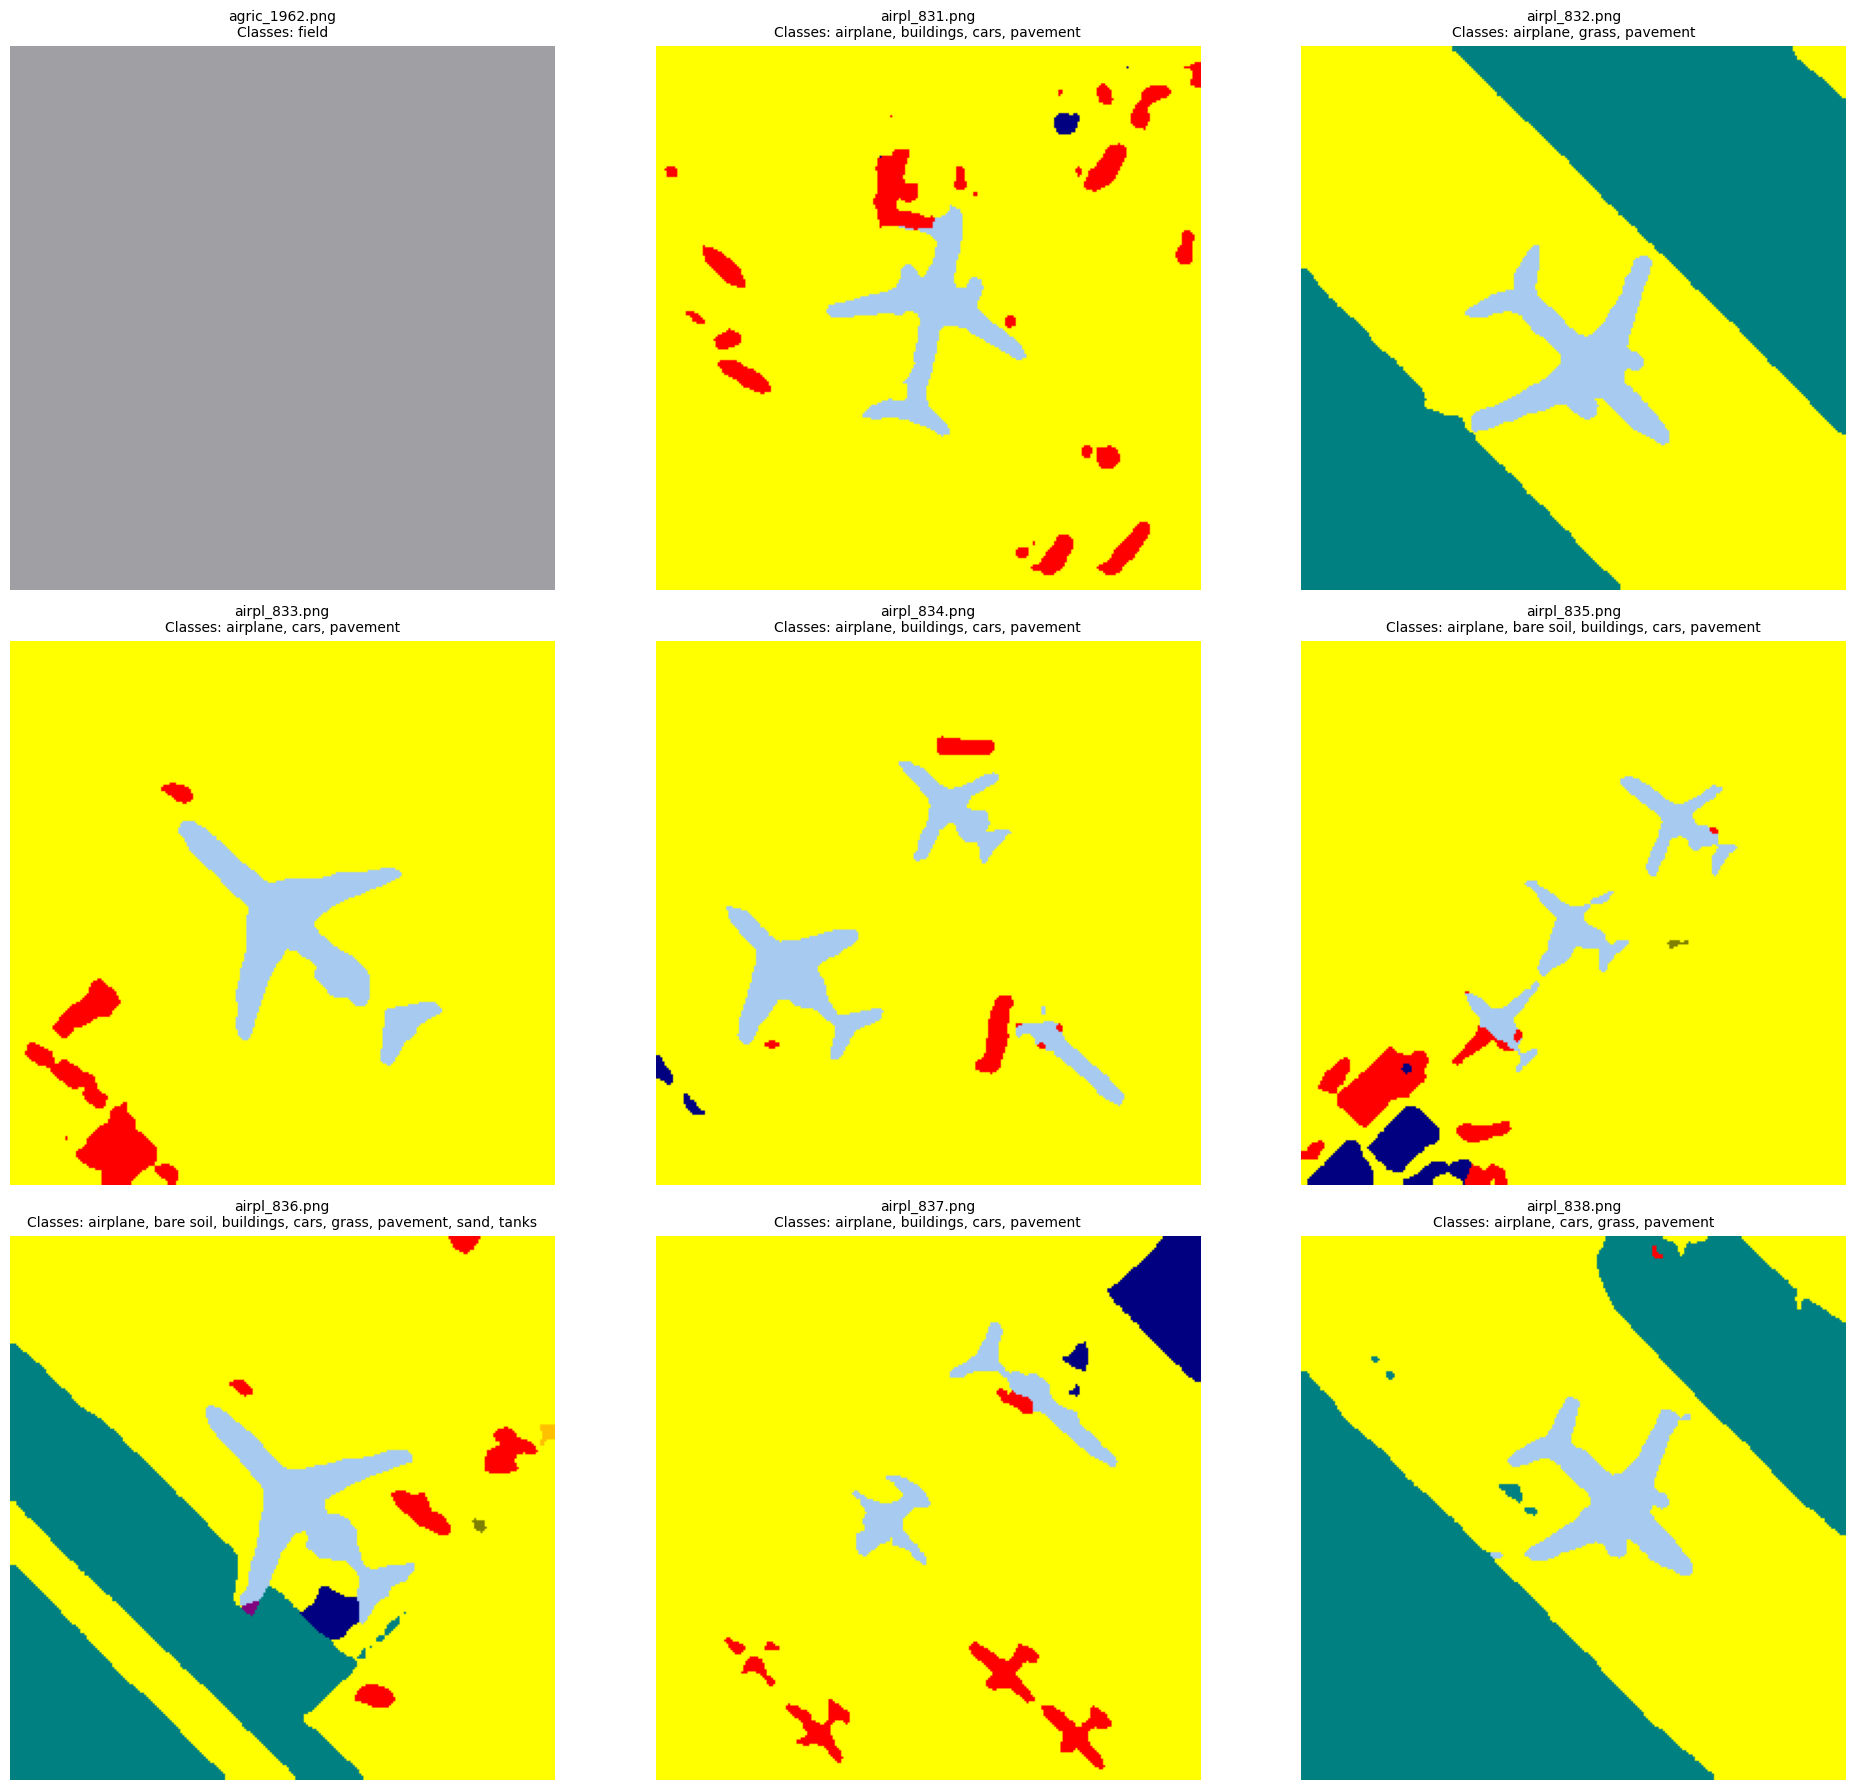


🎯 Initial predictions completed successfully!


In [11]:
import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from torch.optim import Adam
import torch.nn as nn
from glob import glob

# ==================== CONFIGURATION ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_images'
initial_output_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/initial_predictions'
sam_checkpoint = "/home/iiitdmk-param/Desktop/sam_vit_b.pth"
model_type = "vit_b"
pretrained_model_path = 'best_high_iou_sam.pth'

# ==================== CLASS DEFINITIONS ====================
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

NUM_CLASSES = len(CLASS_INFO)

# ==================== MODEL ARCHITECTURE ====================
class HighIoUSAMWrapper(nn.Module):
    def __init__(self, sam_model, num_classes):
        super().__init__()
        self.sam = sam_model
        self.num_classes = num_classes
        
        self.segmentation_head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )
        
        for param in self.sam.parameters():
            param.requires_grad = False
    
    def forward(self, x):
        with torch.no_grad():
            image_embeddings = self.sam.image_encoder(x)
        logits = self.segmentation_head(image_embeddings)
        return logits

# ==================== LOAD PRE-TRAINED MODEL ====================
def load_pretrained_model(pretrained_path, sam_checkpoint, model_type, num_classes):
    print("🔄 Loading SAM base model...")
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    
    print("🔄 Creating wrapper model...")
    model = HighIoUSAMWrapper(sam, num_classes)
    
    print(f"🔄 Loading pre-trained weights from {pretrained_path}...")
    
    if not os.path.exists(pretrained_path):
        raise FileNotFoundError(f"❌ Pre-trained model not found at: {pretrained_path}")
    
    checkpoint = torch.load(pretrained_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    epoch = checkpoint.get('epoch', 'Unknown')
    loss = checkpoint.get('loss', 'Unknown')
    iou = checkpoint.get('iou', 'Unknown')
    
    try:
        loss_str = f"{float(loss):.4f}" if loss != 'Unknown' else 'Unknown'
        iou_str = f"{float(iou):.4f}" if iou != 'Unknown' else 'Unknown'
        print(f"✅ Loaded model from epoch {epoch} with val loss: {loss_str}, IoU: {iou_str}")
    except (ValueError, TypeError):
        print(f"✅ Loaded model from epoch {epoch} with val loss: {loss}, IoU: {iou}")
    
    return model

# ==================== GET INITIAL PREDICTION ====================
def get_initial_prediction(model, image_rgb, original_size, device):
    """Get initial dense 1-channel prediction using your fine-tuned model"""
    # Preprocess image
    input_image = cv2.resize(image_rgb, (1024, 1024))
    input_image = input_image.astype(np.float32) / 255.0
    input_image = (input_image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
    
    input_image_tensor = torch.from_numpy(input_image).permute(2, 0, 1).float().to(device)
    input_image_tensor = input_image_tensor.unsqueeze(0)
    
    with torch.no_grad():
        logits = model(input_image_tensor)
        logits = torch.nn.functional.interpolate(
            logits, size=original_size, mode='bilinear', align_corners=False
        )
        predictions = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    
    return predictions

# ==================== SAVE INITIAL PREDICTIONS ====================
def save_initial_predictions(model, test_image_dir, output_dir, device='cuda'):
    """Save only initial predictions without any refinement"""
    os.makedirs(output_dir, exist_ok=True)
    model.eval()
    
    image_files = sorted([f for f in os.listdir(test_image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
    
    print(f"📸 Found {len(image_files)} test images")
    print(f"💾 Saving initial predictions to: {output_dir}")
    
    for image_idx, image_file in enumerate(image_files, 1):
        image_path = os.path.join(test_image_dir, image_file)
        base_name = image_file.split('.')[0]
        
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            print(f"❌ Could not load image: {image_file}")
            continue
            
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        original_size = image_rgb.shape[:2]
        
        #print(f"[{image_idx}/{len(image_files)}] Processing {image_file}...")
        
        # Get initial 1-channel prediction
        initial_prediction = get_initial_prediction(model, image_rgb, original_size, device)
        
        # Analyze initial prediction
        initial_classes = np.unique(initial_prediction)
        initial_class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in initial_classes]
        #print(f"  📊 Classes: {list(zip(initial_classes, initial_class_names))}")
        
        # Save initial prediction
        predictions_uint8 = initial_prediction.astype(np.uint8)
        output_path = os.path.join(output_dir, f'{image_file}')
        cv2.imwrite(output_path, predictions_uint8)
        #print(f"  ✅ Saved initial prediction: {output_path}")
    
    print("\n🎉 All initial predictions saved!")

# ==================== VISUALIZATION ====================
def visualize_predictions(predictions_folder, num_samples=9):
    """Visualize prediction masks with proper class colors"""
    image_files = sorted([f for f in os.listdir(predictions_folder) if f.endswith(('.png', '.jpg', '.jpeg'))])
    
    if not image_files:
        print("❌ No prediction files found for visualization")
        return
    
    num_images = min(len(image_files), num_samples)
    cols = 3
    rows = (num_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 6*rows))
    if rows > 1:
        axes = axes.flatten()
    else:
        axes = [axes] if cols == 1 else axes
    
    for i, image_file in enumerate(image_files[:num_images]):
        image_path = os.path.join(predictions_folder, image_file)
        mask = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        if mask is None:
            continue
        
        # Create colored mask using class RGB values
        colored_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
        for class_id, info in CLASS_INFO.items():
            colored_mask[mask == class_id] = info["rgb"]
        
        axes[i].imshow(colored_mask)
        
        # Get unique classes in this mask
        unique_classes = np.unique(mask)
        class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in unique_classes]
        
        axes[i].set_title(f'{image_file}\nClasses: {", ".join(class_names)}', fontsize=10)
        axes[i].axis('off')
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

# ==================== MAIN EXECUTION ====================
def main():
    print("🚀 Starting initial predictions...")
    
    # Load your pre-trained fine-tuned model
    model = load_pretrained_model(pretrained_model_path, sam_checkpoint, model_type, NUM_CLASSES)
    model = model.to(device)
    model.eval()
    
    # Save only initial predictions
    save_initial_predictions(model, test_image_dir, initial_output_dir, device)
    
    # Visualize predictions
    visualize_predictions(initial_output_dir)
    
    print("\n🎯 Initial predictions completed successfully!")

if __name__ == "__main__":
    main()

In [16]:
import os
import numpy as np
from PIL import Image

# Define the class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

def calculate_detailed_miou(gt_folder, pred_folder, num_classes=18, ignore_index=None):
    """
    Calculate detailed mIoU with per-class results
    """
    
    gt_files = sorted([f for f in os.listdir(gt_folder) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
    pred_files = sorted([f for f in os.listdir(pred_folder) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
    
    assert len(gt_files) == len(pred_files), f"Number of files don't match: GT={len(gt_files)}, Pred={len(pred_files)}"
    
    # Initialize intersection and union arrays
    total_intersection = np.zeros(num_classes)
    total_union = np.zeros(num_classes)
    class_pixels = np.zeros(num_classes)  # For pixel accuracy
    
    print(f"Processing {len(gt_files)} images...")
    
    for i, (gt_file, pred_file) in enumerate(zip(gt_files, pred_files)):
        gt_path = os.path.join(gt_folder, gt_file)
        pred_path = os.path.join(pred_folder, pred_file)
        
        # Load 1-channel masks
        gt_mask = np.array(Image.open(gt_path))
        pred_mask = np.array(Image.open(pred_path))
        
        # Ensure masks have the same shape
        assert gt_mask.shape == pred_mask.shape, f"Shape mismatch: GT{gt_mask.shape} vs Pred{pred_mask.shape}"
        
        # Calculate IoU for each class
        for class_id in range(num_classes):
            if ignore_index is not None and class_id == ignore_index:
                continue
                
            gt_class = (gt_mask == class_id)
            pred_class = (pred_mask == class_id)
            
            intersection = np.logical_and(gt_class, pred_class).sum()
            union = np.logical_or(gt_class, pred_class).sum()
            
            total_intersection[class_id] += intersection
            total_union[class_id] += union
            class_pixels[class_id] += gt_class.sum()
        
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1}/{len(gt_files)} images")
    
    # Calculate IoU for each class
    iou_per_class = np.zeros(num_classes)
    for class_id in range(num_classes):
        if total_union[class_id] > 0:
            iou_per_class[class_id] = total_intersection[class_id] / total_union[class_id]
        else:
            iou_per_class[class_id] = np.nan
    
    # Calculate mIoU (mean over classes, ignoring NaN)
    valid_classes = ~np.isnan(iou_per_class)
    miou = np.mean(iou_per_class[valid_classes])
    
    # Calculate pixel accuracy
    pixel_accuracy = total_intersection.sum() / class_pixels.sum() if class_pixels.sum() > 0 else 0
    
    return miou, iou_per_class, pixel_accuracy

# Usage with detailed results
gt_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_1cmasks'
pred_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/initial_predictions'
num_classes = 18

miou, iou_per_class, pixel_acc = calculate_detailed_miou(gt_folder, pred_folder, num_classes)

print("\n" + "="*50)
print("SEMANTIC SEGMENTATION RESULTS")
print("="*50)
print(f"mIoU: {miou:.4f}")
print(f"Pixel Accuracy: {pixel_acc:.4f}")
print("\nPer-class IoU:")
for class_id in range(num_classes):
    class_name = CLASS_INFO[class_id]["name"]
    iou = iou_per_class[class_id]
    if not np.isnan(iou):
        print(f"  {class_name:15}: {iou:.4f}")
    else:
        print(f"  {class_name:15}: No pixels")

Processing 1319 images...
Processed 100/1319 images
Processed 200/1319 images
Processed 300/1319 images
Processed 400/1319 images
Processed 500/1319 images
Processed 600/1319 images
Processed 700/1319 images
Processed 800/1319 images
Processed 900/1319 images
Processed 1000/1319 images
Processed 1100/1319 images
Processed 1200/1319 images
Processed 1300/1319 images

SEMANTIC SEGMENTATION RESULTS
mIoU: 0.5842
Pixel Accuracy: 0.7606

Per-class IoU:
  background     : No pixels
  airplane       : 0.5540
  bare soil      : 0.4217
  buildings      : 0.6093
  cars           : 0.7141
  chaparral      : 0.6510
  court          : 0.8227
  dock           : 0.4354
  field          : 0.1149
  grass          : 0.6082
  mobile home    : 0.4427
  pavement       : 0.7401
  sand           : 0.4199
  sea            : 0.8436
  ship           : 0.6435
  tanks          : 0.6783
  trees          : 0.5451
  water          : 0.6861


In [14]:
import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from torch.optim import Adam
import torch.nn as nn
from glob import glob

# ==================== CONFIGURATION ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_images'
point_annotation_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_point_masks'
initial_predictions_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/initial_predictions'
refined_output_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/refined_predictions'
sam_checkpoint = "/home/iiitdmk-param/Desktop/sam_vit_b.pth"
model_type = "vit_b"
pretrained_model_path = 'best_high_iou_sam.pth'

# ==================== CLASS DEFINITIONS ====================
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

NUM_CLASSES = len(CLASS_INFO)

# ==================== POINT ANNOTATION LOADING ====================
def load_point_annotations(point_annotation_dir, image_files):
    """Load RGB point annotations and convert to class coordinates, ignoring (100,100,100) pixels"""
    point_prompts = {}
    ignore_color = np.array([100, 100, 100])
    
    print("🔍 Loading point annotations...")
    
    for image_file in image_files:
        base_name = image_file.split('.')[0]
        point_path = os.path.join(point_annotation_dir, f"{base_name}.png")
        
        if os.path.exists(point_path):
            point_mask = cv2.imread(point_path)
            if point_mask is None:
                continue
                
            point_mask = cv2.cvtColor(point_mask, cv2.COLOR_BGR2RGB)
            original_size = point_mask.shape[:2]
            
            # Create ignore mask (pixels that are NOT ignore color)
            non_ignore_mask = ~np.all(point_mask == ignore_color, axis=-1)
            
            # Extract point prompts for each class
            class_points = {}
            
            for class_id, info in CLASS_INFO.items():
                if class_id == 0:  # Skip background
                    continue
                    
                target_color = np.array(info["rgb"])
                # Find pixels that match this class color AND are not ignore color
                mask = np.all(point_mask == target_color, axis=-1) & non_ignore_mask
                
                if np.any(mask):
                    # Get coordinates of points
                    y_coords, x_coords = np.where(mask)
                    points = list(zip(x_coords, y_coords))
                    class_points[class_id] = points
            
            point_prompts[base_name] = class_points
    
    return point_prompts

# ==================== MODEL ARCHITECTURE ====================
class HighIoUSAMWrapper(nn.Module):
    def __init__(self, sam_model, num_classes):
        super().__init__()
        self.sam = sam_model
        self.num_classes = num_classes
        
        self.segmentation_head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )
        
        for param in self.sam.parameters():
            param.requires_grad = False
    
    def forward(self, x):
        with torch.no_grad():
            image_embeddings = self.sam.image_encoder(x)
        logits = self.segmentation_head(image_embeddings)
        return logits
    
    def get_sam_embedding(self, x):
        """Get SAM image embeddings for point refinement"""
        with torch.no_grad():
            return self.sam.image_encoder(x)
    
    def prompt_guided_prediction(self, image_embedding, point_coords, point_labels):
        """Use SAM's prompt encoder and mask decoder for point refinement"""
        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(
            points=(point_coords, point_labels),
            boxes=None,
            masks=None,
        )
        
        low_res_masks, iou_predictions = self.sam.mask_decoder(
            image_embeddings=image_embedding,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )
        
        return low_res_masks

# ==================== LOAD PRE-TRAINED MODEL ====================
def load_pretrained_model(pretrained_path, sam_checkpoint, model_type, num_classes):
    print("🔄 Loading SAM base model...")
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    
    print("🔄 Creating wrapper model...")
    model = HighIoUSAMWrapper(sam, num_classes)
    
    print(f"🔄 Loading pre-trained weights from {pretrained_path}...")
    
    if not os.path.exists(pretrained_path):
        raise FileNotFoundError(f"❌ Pre-trained model not found at: {pretrained_path}")
    
    checkpoint = torch.load(pretrained_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    return model

# ==================== REFINEMENT FUNCTIONS ====================
def refine_with_points(model, image_rgb, initial_pred, class_points, original_size, device):
    """Refine initial prediction using point prompts with fine-tuned SAM"""
    refined_pred = initial_pred.copy()
    
    if not class_points:
        return refined_pred
    
    # Preprocess image for SAM
    input_image = cv2.resize(image_rgb, (1024, 1024))
    input_image = input_image.astype(np.float32) / 255.0
    input_image = (input_image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
    input_image_tensor = torch.from_numpy(input_image).permute(2, 0, 1).float().to(device)
    
    # Get image embedding from your fine-tuned SAM
    with torch.no_grad():
        image_embedding = model.get_sam_embedding(input_image_tensor.unsqueeze(0))
    
    # Process each class with point prompts
    total_refined_pixels = 0
    
    for class_id, points in class_points.items():
        if len(points) == 0:
            continue
            
        #print(f"    🎯 Refining {CLASS_INFO[class_id]['name']} with {len(points)} points...")
        class_refined_pixels = 0
        
        for point_idx, point in enumerate(points):
            x, y = point
            
            # Scale points to 1024x1024
            x_scale = 1024 / original_size[1]
            y_scale = 1024 / original_size[0]
            x_sam = int(x * x_scale)
            y_sam = int(y * y_scale)
            
            # Ensure coordinates are within bounds
            x_sam = max(0, min(x_sam, 1023))
            y_sam = max(0, min(y_sam, 1023))
            
            # Create point prompt
            point_coords = torch.tensor([[[x_sam, y_sam]]], device=device).float()
            point_labels = torch.tensor([[1]], device=device).long()
            
            # Get mask prediction from your fine-tuned SAM
            with torch.no_grad():
                low_res_masks = model.prompt_guided_prediction(
                    image_embedding, point_coords, point_labels
                )
                
                # Upscale mask to original size
                mask = torch.nn.functional.interpolate(
                    low_res_masks,
                    size=original_size,
                    mode="bilinear",
                    align_corners=False,
                )
                mask = mask.squeeze().cpu().numpy() > 0.0
            
            # Count how many pixels we're refining
            pixels_refined = np.sum(mask)
            class_refined_pixels += pixels_refined
            
            # OVERWRITE the entire region with the correct class ID
            refined_pred[mask] = class_id
        
        total_refined_pixels += class_refined_pixels
        #print(f"      ✅ {CLASS_INFO[class_id]['name']}: {class_refined_pixels} pixels refined")
    
    #print(f"    📊 Total refinement: {total_refined_pixels} pixels updated")
    return refined_pred

# ==================== REFINEMENT ONLY ====================
def refine_predictions_only(model, point_prompts, test_image_dir, initial_predictions_dir, refined_output_dir, device='cuda'):
    """Refine existing initial predictions using point prompts"""
    os.makedirs(refined_output_dir, exist_ok=True)
    model.eval()
    
    image_files = sorted([f for f in os.listdir(test_image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
    
    print(f"📸 Found {len(image_files)} test images")
    print(f"💾 Loading initial predictions from: {initial_predictions_dir}")
    print(f"💾 Saving refined predictions to: {refined_output_dir}")
    
    for image_idx, image_file in enumerate(image_files, 1):
        image_path = os.path.join(test_image_dir, image_file)
        base_name = image_file.split('.')[0]
        
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            print(f"❌ Could not load image: {image_file}")
            continue
            
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        original_size = image_rgb.shape[:2]
        
        # Load initial prediction
        initial_pred_path = os.path.join(initial_predictions_dir, image_file)
        if not os.path.exists(initial_pred_path):
            print(f"❌ Initial prediction not found: {initial_pred_path}")
            continue
            
        initial_prediction = cv2.imread(initial_pred_path, cv2.IMREAD_GRAYSCALE)
        if initial_prediction is None:
            print(f"❌ Could not load initial prediction: {initial_pred_path}")
            continue
        
        #print(f"[{image_idx}/{len(image_files)}] 🔄 Refining {image_file}...")
        
        # Analyze initial prediction
        initial_classes = np.unique(initial_prediction)
        initial_class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in initial_classes]
        #print(f"  📊 Initial classes: {list(zip(initial_classes, initial_class_names))}")
        
        # Refine with point prompts if available
        if base_name in point_prompts and point_prompts[base_name]:
            #print(f"  🔧 Refining with point annotations...")
            refined_prediction = refine_with_points(
                model, image_rgb, initial_prediction, point_prompts[base_name], original_size, device
            )
            refinement_type = "REFINED"
        else:
            refined_prediction = initial_prediction
            print(f"  ⚠️  No point annotations found, using initial prediction")
            refinement_type = "INITIAL"
        
        # Save refined prediction
        predictions_uint8 = refined_prediction.astype(np.uint8)
        output_path = os.path.join(refined_output_dir, f'{image_file}')
        cv2.imwrite(output_path, predictions_uint8)
        
        # Analyze final prediction
        final_classes = np.unique(refined_prediction)
        final_class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in final_classes]
        #print(f"  ✅ Saved {refinement_type} mask - Classes: {list(zip(final_classes, final_class_names))}")
    
    print("\n🎉 All refinements completed!")

# ==================== MAIN EXECUTION ====================
def main():
    print("🚀 Starting refinement of initial predictions...")
    
    # Load your pre-trained fine-tuned model
    model = load_pretrained_model(pretrained_model_path, sam_checkpoint, model_type, NUM_CLASSES)
    model = model.to(device)
    model.eval()
    
    # Load point annotations
    test_image_files = sorted([f for f in os.listdir(test_image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
    point_prompts = load_point_annotations(point_annotation_dir, test_image_files)
    
    # Refine existing initial predictions
    refine_predictions_only(model, point_prompts, test_image_dir, initial_predictions_dir, refined_output_dir, device)
    
    print("\n🎯 Refinement completed successfully!")

if __name__ == "__main__":
    main()

🚀 Starting refinement of initial predictions...
🔄 Loading SAM base model...
🔄 Creating wrapper model...
🔄 Loading pre-trained weights from best_high_iou_sam.pth...
🔍 Loading point annotations...
📸 Found 1319 test images
💾 Loading initial predictions from: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/initial_predictions
💾 Saving refined predictions to: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/refined_predictions

🎉 All refinements completed!

🎯 Refinement completed successfully!


In [15]:
import os
import numpy as np
from PIL import Image

# Define the class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

def calculate_detailed_miou(gt_folder, pred_folder, num_classes=18, ignore_index=None):
    """
    Calculate detailed mIoU with per-class results
    """
    
    gt_files = sorted([f for f in os.listdir(gt_folder) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
    pred_files = sorted([f for f in os.listdir(pred_folder) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
    
    assert len(gt_files) == len(pred_files), f"Number of files don't match: GT={len(gt_files)}, Pred={len(pred_files)}"
    
    # Initialize intersection and union arrays
    total_intersection = np.zeros(num_classes)
    total_union = np.zeros(num_classes)
    class_pixels = np.zeros(num_classes)  # For pixel accuracy
    
    print(f"Processing {len(gt_files)} images...")
    
    for i, (gt_file, pred_file) in enumerate(zip(gt_files, pred_files)):
        gt_path = os.path.join(gt_folder, gt_file)
        pred_path = os.path.join(pred_folder, pred_file)
        
        # Load 1-channel masks
        gt_mask = np.array(Image.open(gt_path))
        pred_mask = np.array(Image.open(pred_path))
        
        # Ensure masks have the same shape
        assert gt_mask.shape == pred_mask.shape, f"Shape mismatch: GT{gt_mask.shape} vs Pred{pred_mask.shape}"
        
        # Calculate IoU for each class
        for class_id in range(num_classes):
            if ignore_index is not None and class_id == ignore_index:
                continue
                
            gt_class = (gt_mask == class_id)
            pred_class = (pred_mask == class_id)
            
            intersection = np.logical_and(gt_class, pred_class).sum()
            union = np.logical_or(gt_class, pred_class).sum()
            
            total_intersection[class_id] += intersection
            total_union[class_id] += union
            class_pixels[class_id] += gt_class.sum()
        
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1}/{len(gt_files)} images")
    
    # Calculate IoU for each class
    iou_per_class = np.zeros(num_classes)
    for class_id in range(num_classes):
        if total_union[class_id] > 0:
            iou_per_class[class_id] = total_intersection[class_id] / total_union[class_id]
        else:
            iou_per_class[class_id] = np.nan
    
    # Calculate mIoU (mean over classes, ignoring NaN)
    valid_classes = ~np.isnan(iou_per_class)
    miou = np.mean(iou_per_class[valid_classes])
    
    # Calculate pixel accuracy
    pixel_accuracy = total_intersection.sum() / class_pixels.sum() if class_pixels.sum() > 0 else 0
    
    return miou, iou_per_class, pixel_accuracy

# Usage with detailed results
gt_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_1cmasks'
pred_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/refined_predictions'
num_classes = 18

miou, iou_per_class, pixel_acc = calculate_detailed_miou(gt_folder, pred_folder, num_classes)

print("\n" + "="*50)
print("SEMANTIC SEGMENTATION RESULTS")
print("="*50)
print(f"mIoU: {miou:.4f}")
print(f"Pixel Accuracy: {pixel_acc:.4f}")
print("\nPer-class IoU:")
for class_id in range(num_classes):
    class_name = CLASS_INFO[class_id]["name"]
    iou = iou_per_class[class_id]
    if not np.isnan(iou):
        print(f"  {class_name:15}: {iou:.4f}")
    else:
        print(f"  {class_name:15}: No pixels")

Processing 1319 images...
Processed 100/1319 images
Processed 200/1319 images
Processed 300/1319 images
Processed 400/1319 images
Processed 500/1319 images
Processed 600/1319 images
Processed 700/1319 images
Processed 800/1319 images
Processed 900/1319 images
Processed 1000/1319 images
Processed 1100/1319 images
Processed 1200/1319 images
Processed 1300/1319 images

SEMANTIC SEGMENTATION RESULTS
mIoU: 0.5933
Pixel Accuracy: 0.7610

Per-class IoU:
  background     : No pixels
  airplane       : 0.6375
  bare soil      : 0.3991
  buildings      : 0.6261
  cars           : 0.6785
  chaparral      : 0.4451
  court          : 0.7790
  dock           : 0.4952
  field          : 0.2379
  grass          : 0.6352
  mobile home    : 0.5383
  pavement       : 0.7250
  sand           : 0.5111
  sea            : 0.8511
  ship           : 0.5603
  tanks          : 0.6791
  trees          : 0.5545
  water          : 0.7338


In [4]:

import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from torch.optim import Adam
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ==================== CONFIGURATION ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths
train_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images'#a1#'/home/iiitdmk-param/Desktop/Meher/Data/strong_images'
train_mask_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_1cmasks'#a2# '/home/iiitdmk-param/Desktop/Meher/Data/strong_labels' 
val_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images'#'/home/iiitdmk-param/Desktop/Meher/Data/weak_images'
val_mask_dir =  '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_1cmasks' #a2#'/home/iiitdmk-param/Desktop/Meher/Data/weak_labels'
sam_checkpoint = "/home/iiitdmk-param/Desktop/Research/3/Data/sam_vit_b.pth"
model_type = "vit_b"

# Training parameters
BATCH_SIZE = 4
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
NUM_CLASSES = 18

# ==================== CLASS INFORMATION ====================
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

class SimpleTransform:
    def __call__(self, image, mask):
        # Resize to 256x256 and normalize
        image = cv2.resize(image, (256, 256))
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        
        # Normalize image
        image = image.astype(np.float32) / 255.0
        image = (image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
        
        # Convert to tensor
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).long()  # Ensure long type
        
        return image, mask

# ==================== MODEL ARCHITECTURE ====================
class HighIoUSAMWrapper(nn.Module):
    def __init__(self, sam_model, num_classes):
        super().__init__()
        self.sam = sam_model
        self.num_classes = num_classes
        
        # Simple segmentation head
        self.segmentation_head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )
        
        # Freeze SAM encoder
        for param in self.sam.image_encoder.parameters():
            param.requires_grad = False
    
    def unfreeze_encoder(self, percentage=0.5):
        total_layers = len(list(self.sam.image_encoder.parameters()))
        layers_to_unfreeze = int(total_layers * percentage)
        
        for i, param in enumerate(self.sam.image_encoder.parameters()):
            if i >= (total_layers - layers_to_unfreeze):
                param.requires_grad = True
    
    def forward(self, x):
        # Input should be 1024x1024 for SAM
        image_embeddings = self.sam.image_encoder(x)
        logits = self.segmentation_head(image_embeddings)
        return logits

# ==================== SIMPLE LOSS FUNCTION ====================
class SimpleLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ce_loss = nn.CrossEntropyLoss()
    
    def forward(self, inputs, targets):
        return self.ce_loss(inputs, targets)

# ==================== DATASET ====================
class HighIoUDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        
        self.image_files = sorted([f for f in os.listdir(image_dir) 
                                 if f.endswith(('.png', '.jpg', '.jpeg', '.tif'))])
        
        print(f"Found {len(self.image_files)} images in {image_dir}")
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        base_name = os.path.splitext(self.image_files[idx])[0]
        mask_path = os.path.join(self.mask_dir, base_name + '.png')
        
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Could not load image: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"Could not load mask: {mask_path}")
        
        # Apply transformations
        if self.transform:
            image, mask = self.transform(image, mask)
        else:
            # Default processing
            image = cv2.resize(image, (256, 256))
            mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).long()
        
        return {'image': image, 'mask': mask}

# ==================== FIXED METRICS ====================
def calculate_iou(pred_mask, true_mask, num_classes):
    ious = []
    
    for class_id in range(num_classes):
        pred_inds = (pred_mask == class_id)
        target_inds = (true_mask == class_id)
        
        intersection = np.logical_and(pred_inds, target_inds).sum()
        union = np.logical_or(pred_inds, target_inds).sum()
        
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(float(intersection / union))
    
    return np.nanmean(ious)

Using device: cuda


In [ ]:
# ==================== MEMORY-SAFE PHASE 2: FINE-TUNING ONLY ====================

def phase2_fine_tuning_only():
    print("=== PHASE 2: FINE-TUNING ONLY ===")
    
    # Clear GPU memory first
    torch.cuda.empty_cache()
    
    # Load the best model checkpoint
    checkpoint = torch.load('best_high_iou_sam.pth', map_location=device)
    print(f"✅ Loaded best model with IoU: {checkpoint['iou']:.4f}")
    
    # Load SAM model
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    model = HighIoUSAMWrapper(sam, NUM_CLASSES).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Step 4: Simple fine-tuning with memory safety (USING ONLY STRONG DATA)
    print("\n🎯 Step 4: Memory-safe fine-tuning with strong data only...")
    
    # Use only strong data for fine-tuning to save memory
    transform = SimpleTransform()
    train_dataset = HighIoUDataset(train_image_dir, train_mask_dir, transform)
    
    # Very small batch size for memory safety
    train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=0)
    
    # Create final model
    sam_final = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    final_model = HighIoUSAMWrapper(sam_final, NUM_CLASSES).to(device)
    final_model.load_state_dict(checkpoint['model_state_dict'])
    
    optimizer = Adam(final_model.parameters(), lr=1e-5)
    criterion = SimpleLoss()
    
    best_final_iou = checkpoint['iou']
    
    # Quick fine-tuning (5 epochs only)
    print("Starting memory-safe fine-tuning (5 epochs)...")
    for epoch in range(100):
        final_model.train()
        epoch_loss = 0
        
        for batch_idx, batch in enumerate(train_loader):
            # Clear memory
            torch.cuda.empty_cache()
            
            images = batch['image'].to(device)
            masks = batch['mask'].to(device).long()
            
            optimizer.zero_grad()
            
            # Process with memory safety
            images_resized = F.interpolate(images, size=1024, mode='bilinear', align_corners=False)
            logits = final_model(images_resized)
            logits = F.interpolate(logits, size=256, mode='bilinear', align_corners=False)
            
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # Print loss before clearing memory
            if batch_idx % 50 == 0:
                print(f'Fine-tuning Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item():.4f}')
            
            # Clear memory after each batch (but after printing)
            del images, masks, images_resized, logits, loss
        
        avg_loss = epoch_loss / len(train_loader)
        print(f'Fine-tuning Epoch {epoch+1}: Avg Loss: {avg_loss:.4f}')
    
    # Save final model
    torch.save({
        'model_state_dict': final_model.state_dict(),
        'iou': best_final_iou,
        'phase': 'phase2_fine_tuning_only',
        'epochs_trained': 5,
        'final_loss': avg_loss
    }, 'phase2_final_sam.pth')
    
    print(f"\n🎯 PHASE 2 COMPLETED SUCCESSFULLY!")
    print(f"✅ Final model saved as: phase2_final_sam.pth")
    print(f"📊 Original IoU: {checkpoint['iou']:.4f}")
    print(f"📊 Final IoU: {best_final_iou:.4f}")
    print(f"📊 Training completed: 5 epochs")
    
    # Create summary file
    summary_path = "phase2_summary.txt"
    with open(summary_path, 'w') as f:
        f.write("=== PHASE 2 SUMMARY (FINE-TUNING ONLY) ===\n")
        f.write(f"Training epochs: 5\n")
        f.write(f"Batch size: 1\n")
        f.write(f"Learning rate: 1e-5\n")
        f.write(f"Training samples: {len(train_dataset)}\n")
        f.write(f"Original model IoU: {checkpoint['iou']:.4f}\n")
        f.write(f"Final model IoU: {best_final_iou:.4f}\n")
        f.write(f"Final average loss: {avg_loss:.4f}\n")
    
    print(f"📄 Summary saved as: {summary_path}")
    
    return final_model, best_final_iou

# Run Fine-tuning Only Phase 2
final_model, final_iou = phase2_fine_tuning_only()

print(f"\n🚀 READY FOR TESTING!")
print(f"Use 'phase2_final_sam.pth' for your test predictions")

🚀 Starting initial predictions...
🔄 Loading SAM base model...
🔄 Creating wrapper model...
🔄 Loading pre-trained weights from phase2_final_sam.pth...
✅ Loaded model from epoch Unknown with val loss: Unknown, IoU: 0.9108
📸 Found 1319 test images
💾 Saving initial predictions to: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/initial_p2_predictions

🎉 All initial predictions saved!


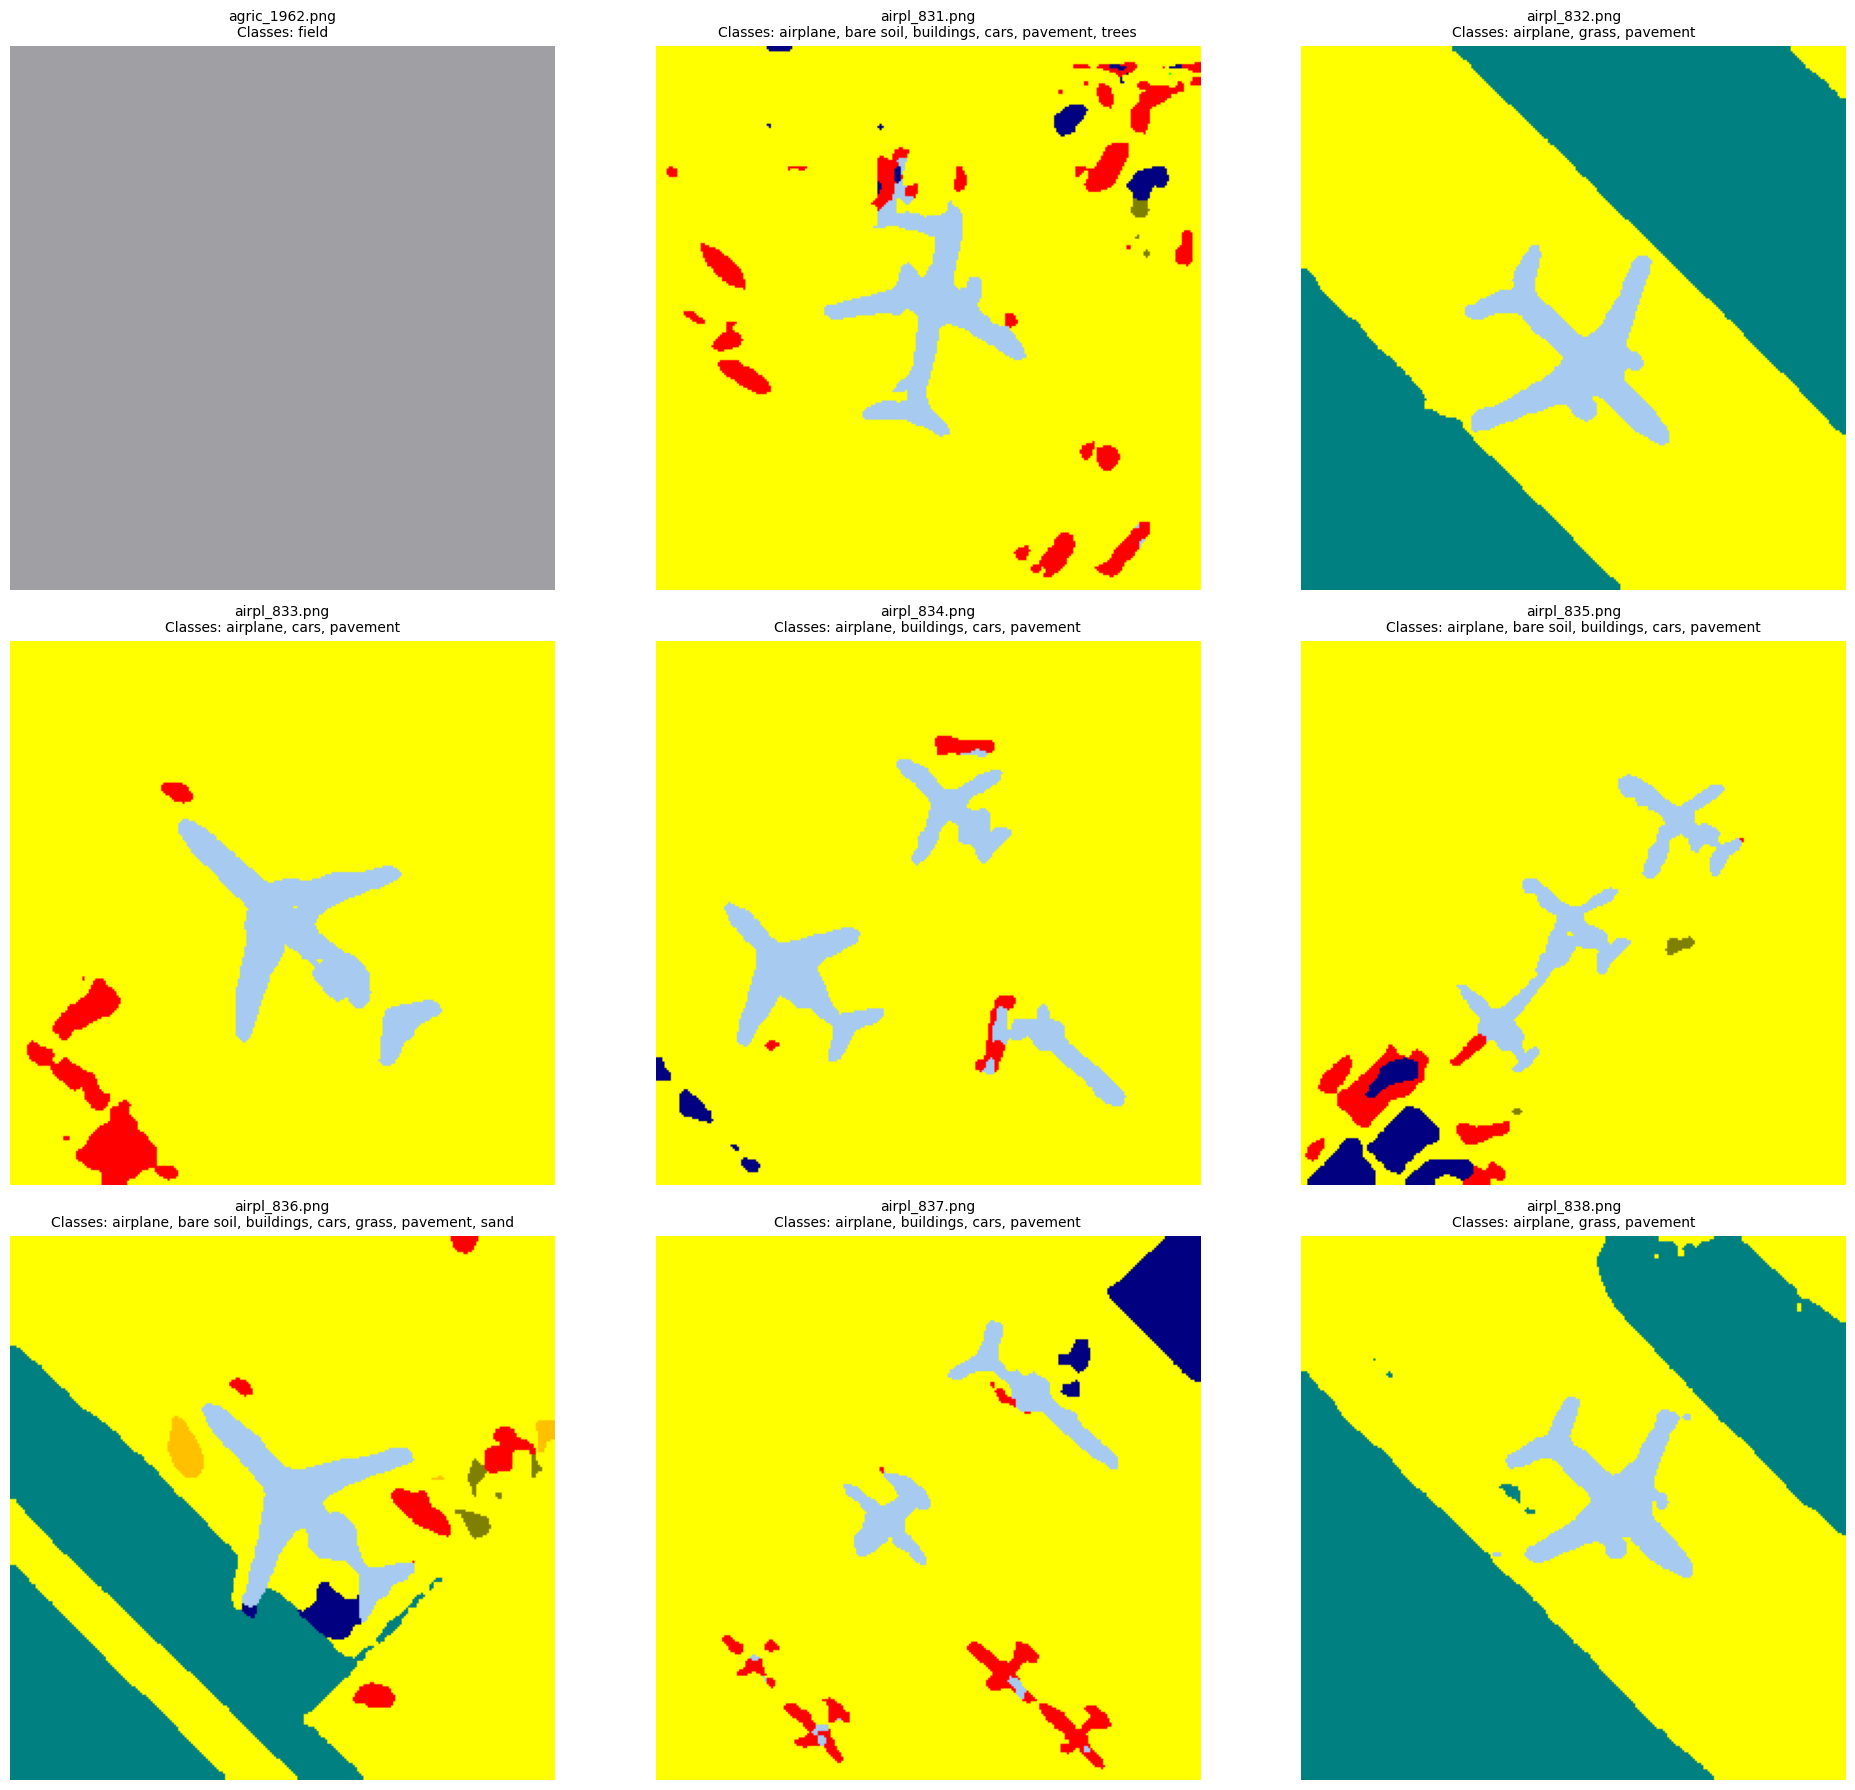


🎯 Initial predictions completed successfully!


In [18]:
import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from torch.optim import Adam
import torch.nn as nn
from glob import glob

# ==================== CONFIGURATION ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_images'
initial_output_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/initial_p2_predictions'
sam_checkpoint = "/home/iiitdmk-param/Desktop/sam_vit_b.pth"
model_type = "vit_b"
pretrained_model_path = 'phase2_final_sam.pth'

# ==================== CLASS DEFINITIONS ====================
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

NUM_CLASSES = len(CLASS_INFO)

# ==================== MODEL ARCHITECTURE ====================
class HighIoUSAMWrapper(nn.Module):
    def __init__(self, sam_model, num_classes):
        super().__init__()
        self.sam = sam_model
        self.num_classes = num_classes
        
        self.segmentation_head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )
        
        for param in self.sam.parameters():
            param.requires_grad = False
    
    def forward(self, x):
        with torch.no_grad():
            image_embeddings = self.sam.image_encoder(x)
        logits = self.segmentation_head(image_embeddings)
        return logits

# ==================== LOAD PRE-TRAINED MODEL ====================
def load_pretrained_model(pretrained_path, sam_checkpoint, model_type, num_classes):
    print("🔄 Loading SAM base model...")
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    
    print("🔄 Creating wrapper model...")
    model = HighIoUSAMWrapper(sam, num_classes)
    
    print(f"🔄 Loading pre-trained weights from {pretrained_path}...")
    
    if not os.path.exists(pretrained_path):
        raise FileNotFoundError(f"❌ Pre-trained model not found at: {pretrained_path}")
    
    checkpoint = torch.load(pretrained_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    epoch = checkpoint.get('epoch', 'Unknown')
    loss = checkpoint.get('loss', 'Unknown')
    iou = checkpoint.get('iou', 'Unknown')
    
    try:
        loss_str = f"{float(loss):.4f}" if loss != 'Unknown' else 'Unknown'
        iou_str = f"{float(iou):.4f}" if iou != 'Unknown' else 'Unknown'
        print(f"✅ Loaded model from epoch {epoch} with val loss: {loss_str}, IoU: {iou_str}")
    except (ValueError, TypeError):
        print(f"✅ Loaded model from epoch {epoch} with val loss: {loss}, IoU: {iou}")
    
    return model

# ==================== GET INITIAL PREDICTION ====================
def get_initial_prediction(model, image_rgb, original_size, device):
    """Get initial dense 1-channel prediction using your fine-tuned model"""
    # Preprocess image
    input_image = cv2.resize(image_rgb, (1024, 1024))
    input_image = input_image.astype(np.float32) / 255.0
    input_image = (input_image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
    
    input_image_tensor = torch.from_numpy(input_image).permute(2, 0, 1).float().to(device)
    input_image_tensor = input_image_tensor.unsqueeze(0)
    
    with torch.no_grad():
        logits = model(input_image_tensor)
        logits = torch.nn.functional.interpolate(
            logits, size=original_size, mode='bilinear', align_corners=False
        )
        predictions = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    
    return predictions

# ==================== SAVE INITIAL PREDICTIONS ====================
def save_initial_predictions(model, test_image_dir, output_dir, device='cuda'):
    """Save only initial predictions without any refinement"""
    os.makedirs(output_dir, exist_ok=True)
    model.eval()
    
    image_files = sorted([f for f in os.listdir(test_image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
    
    print(f"📸 Found {len(image_files)} test images")
    print(f"💾 Saving initial predictions to: {output_dir}")
    
    for image_idx, image_file in enumerate(image_files, 1):
        image_path = os.path.join(test_image_dir, image_file)
        base_name = image_file.split('.')[0]
        
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            print(f"❌ Could not load image: {image_file}")
            continue
            
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        original_size = image_rgb.shape[:2]
        
        #print(f"[{image_idx}/{len(image_files)}] Processing {image_file}...")
        
        # Get initial 1-channel prediction
        initial_prediction = get_initial_prediction(model, image_rgb, original_size, device)
        
        # Analyze initial prediction
        initial_classes = np.unique(initial_prediction)
        initial_class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in initial_classes]
        #print(f"  📊 Classes: {list(zip(initial_classes, initial_class_names))}")
        
        # Save initial prediction
        predictions_uint8 = initial_prediction.astype(np.uint8)
        output_path = os.path.join(output_dir, f'{image_file}')
        cv2.imwrite(output_path, predictions_uint8)
        #print(f"  ✅ Saved initial prediction: {output_path}")
    
    print("\n🎉 All initial predictions saved!")

# ==================== VISUALIZATION ====================
def visualize_predictions(predictions_folder, num_samples=9):
    """Visualize prediction masks with proper class colors"""
    image_files = sorted([f for f in os.listdir(predictions_folder) if f.endswith(('.png', '.jpg', '.jpeg'))])
    
    if not image_files:
        print("❌ No prediction files found for visualization")
        return
    
    num_images = min(len(image_files), num_samples)
    cols = 3
    rows = (num_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 6*rows))
    if rows > 1:
        axes = axes.flatten()
    else:
        axes = [axes] if cols == 1 else axes
    
    for i, image_file in enumerate(image_files[:num_images]):
        image_path = os.path.join(predictions_folder, image_file)
        mask = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        if mask is None:
            continue
        
        # Create colored mask using class RGB values
        colored_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
        for class_id, info in CLASS_INFO.items():
            colored_mask[mask == class_id] = info["rgb"]
        
        axes[i].imshow(colored_mask)
        
        # Get unique classes in this mask
        unique_classes = np.unique(mask)
        class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in unique_classes]
        
        axes[i].set_title(f'{image_file}\nClasses: {", ".join(class_names)}', fontsize=10)
        axes[i].axis('off')
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

# ==================== MAIN EXECUTION ====================
def main():
    print("🚀 Starting initial predictions...")
    
    # Load your pre-trained fine-tuned model
    model = load_pretrained_model(pretrained_model_path, sam_checkpoint, model_type, NUM_CLASSES)
    model = model.to(device)
    model.eval()
    
    # Save only initial predictions
    save_initial_predictions(model, test_image_dir, initial_output_dir, device)
    
    # Visualize predictions
    visualize_predictions(initial_output_dir)
    
    print("\n🎯 Initial predictions completed successfully!")

if __name__ == "__main__":
    main()

In [19]:
import os
import numpy as np
from PIL import Image

# Define the class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

def calculate_detailed_miou(gt_folder, pred_folder, num_classes=18, ignore_index=None):
    """
    Calculate detailed mIoU with per-class results
    """
    
    gt_files = sorted([f for f in os.listdir(gt_folder) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
    pred_files = sorted([f for f in os.listdir(pred_folder) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
    
    assert len(gt_files) == len(pred_files), f"Number of files don't match: GT={len(gt_files)}, Pred={len(pred_files)}"
    
    # Initialize intersection and union arrays
    total_intersection = np.zeros(num_classes)
    total_union = np.zeros(num_classes)
    class_pixels = np.zeros(num_classes)  # For pixel accuracy
    
    print(f"Processing {len(gt_files)} images...")
    
    for i, (gt_file, pred_file) in enumerate(zip(gt_files, pred_files)):
        gt_path = os.path.join(gt_folder, gt_file)
        pred_path = os.path.join(pred_folder, pred_file)
        
        # Load 1-channel masks
        gt_mask = np.array(Image.open(gt_path))
        pred_mask = np.array(Image.open(pred_path))
        
        # Ensure masks have the same shape
        assert gt_mask.shape == pred_mask.shape, f"Shape mismatch: GT{gt_mask.shape} vs Pred{pred_mask.shape}"
        
        # Calculate IoU for each class
        for class_id in range(num_classes):
            if ignore_index is not None and class_id == ignore_index:
                continue
                
            gt_class = (gt_mask == class_id)
            pred_class = (pred_mask == class_id)
            
            intersection = np.logical_and(gt_class, pred_class).sum()
            union = np.logical_or(gt_class, pred_class).sum()
            
            total_intersection[class_id] += intersection
            total_union[class_id] += union
            class_pixels[class_id] += gt_class.sum()
        
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1}/{len(gt_files)} images")
    
    # Calculate IoU for each class
    iou_per_class = np.zeros(num_classes)
    for class_id in range(num_classes):
        if total_union[class_id] > 0:
            iou_per_class[class_id] = total_intersection[class_id] / total_union[class_id]
        else:
            iou_per_class[class_id] = np.nan
    
    # Calculate mIoU (mean over classes, ignoring NaN)
    valid_classes = ~np.isnan(iou_per_class)
    miou = np.mean(iou_per_class[valid_classes])
    
    # Calculate pixel accuracy
    pixel_accuracy = total_intersection.sum() / class_pixels.sum() if class_pixels.sum() > 0 else 0
    
    return miou, iou_per_class, pixel_accuracy

# Usage with detailed results
gt_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_1cmasks'
pred_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/initial_p2_predictions'
num_classes = 18

miou, iou_per_class, pixel_acc = calculate_detailed_miou(gt_folder, pred_folder, num_classes)

print("\n" + "="*50)
print("SEMANTIC SEGMENTATION RESULTS")
print("="*50)
print(f"mIoU: {miou:.4f}")
print(f"Pixel Accuracy: {pixel_acc:.4f}")
print("\nPer-class IoU:")
for class_id in range(num_classes):
    class_name = CLASS_INFO[class_id]["name"]
    iou = iou_per_class[class_id]
    if not np.isnan(iou):
        print(f"  {class_name:15}: {iou:.4f}")
    else:
        print(f"  {class_name:15}: No pixels")

Processing 1319 images...
Processed 100/1319 images
Processed 200/1319 images
Processed 300/1319 images
Processed 400/1319 images
Processed 500/1319 images
Processed 600/1319 images
Processed 700/1319 images
Processed 800/1319 images
Processed 900/1319 images
Processed 1000/1319 images
Processed 1100/1319 images
Processed 1200/1319 images
Processed 1300/1319 images

SEMANTIC SEGMENTATION RESULTS
mIoU: 0.5691
Pixel Accuracy: 0.7540

Per-class IoU:
  background     : No pixels
  airplane       : 0.5583
  bare soil      : 0.4300
  buildings      : 0.5990
  cars           : 0.7123
  chaparral      : 0.4895
  court          : 0.8076
  dock           : 0.3859
  field          : 0.1167
  grass          : 0.6093
  mobile home    : 0.4302
  pavement       : 0.7343
  sand           : 0.4223
  sea            : 0.8365
  ship           : 0.6356
  tanks          : 0.6697
  trees          : 0.5400
  water          : 0.6970


In [20]:
import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from torch.optim import Adam
import torch.nn as nn
from glob import glob

# ==================== CONFIGURATION ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_images'
point_annotation_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_point_masks'
initial_predictions_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/initial_p2_predictions'
refined_output_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/refined_p2_predictions'
sam_checkpoint = "/home/iiitdmk-param/Desktop/sam_vit_b.pth"
model_type = "vit_b"
pretrained_model_path = 'phase2_final_sam.pth'

# ==================== CLASS DEFINITIONS ====================
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

NUM_CLASSES = len(CLASS_INFO)

# ==================== POINT ANNOTATION LOADING ====================
def load_point_annotations(point_annotation_dir, image_files):
    """Load RGB point annotations and convert to class coordinates, ignoring (100,100,100) pixels"""
    point_prompts = {}
    ignore_color = np.array([100, 100, 100])
    
    print("🔍 Loading point annotations...")
    
    for image_file in image_files:
        base_name = image_file.split('.')[0]
        point_path = os.path.join(point_annotation_dir, f"{base_name}.png")
        
        if os.path.exists(point_path):
            point_mask = cv2.imread(point_path)
            if point_mask is None:
                continue
                
            point_mask = cv2.cvtColor(point_mask, cv2.COLOR_BGR2RGB)
            original_size = point_mask.shape[:2]
            
            # Create ignore mask (pixels that are NOT ignore color)
            non_ignore_mask = ~np.all(point_mask == ignore_color, axis=-1)
            
            # Extract point prompts for each class
            class_points = {}
            
            for class_id, info in CLASS_INFO.items():
                if class_id == 0:  # Skip background
                    continue
                    
                target_color = np.array(info["rgb"])
                # Find pixels that match this class color AND are not ignore color
                mask = np.all(point_mask == target_color, axis=-1) & non_ignore_mask
                
                if np.any(mask):
                    # Get coordinates of points
                    y_coords, x_coords = np.where(mask)
                    points = list(zip(x_coords, y_coords))
                    class_points[class_id] = points
            
            point_prompts[base_name] = class_points
    
    return point_prompts

# ==================== MODEL ARCHITECTURE ====================
class HighIoUSAMWrapper(nn.Module):
    def __init__(self, sam_model, num_classes):
        super().__init__()
        self.sam = sam_model
        self.num_classes = num_classes
        
        self.segmentation_head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )
        
        for param in self.sam.parameters():
            param.requires_grad = False
    
    def forward(self, x):
        with torch.no_grad():
            image_embeddings = self.sam.image_encoder(x)
        logits = self.segmentation_head(image_embeddings)
        return logits
    
    def get_sam_embedding(self, x):
        """Get SAM image embeddings for point refinement"""
        with torch.no_grad():
            return self.sam.image_encoder(x)
    
    def prompt_guided_prediction(self, image_embedding, point_coords, point_labels):
        """Use SAM's prompt encoder and mask decoder for point refinement"""
        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(
            points=(point_coords, point_labels),
            boxes=None,
            masks=None,
        )
        
        low_res_masks, iou_predictions = self.sam.mask_decoder(
            image_embeddings=image_embedding,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )
        
        return low_res_masks

# ==================== LOAD PRE-TRAINED MODEL ====================
def load_pretrained_model(pretrained_path, sam_checkpoint, model_type, num_classes):
    print("🔄 Loading SAM base model...")
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    
    print("🔄 Creating wrapper model...")
    model = HighIoUSAMWrapper(sam, num_classes)
    
    print(f"🔄 Loading pre-trained weights from {pretrained_path}...")
    
    if not os.path.exists(pretrained_path):
        raise FileNotFoundError(f"❌ Pre-trained model not found at: {pretrained_path}")
    
    checkpoint = torch.load(pretrained_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    return model

# ==================== REFINEMENT FUNCTIONS ====================
def refine_with_points(model, image_rgb, initial_pred, class_points, original_size, device):
    """Refine initial prediction using point prompts with fine-tuned SAM"""
    refined_pred = initial_pred.copy()
    
    if not class_points:
        return refined_pred
    
    # Preprocess image for SAM
    input_image = cv2.resize(image_rgb, (1024, 1024))
    input_image = input_image.astype(np.float32) / 255.0
    input_image = (input_image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
    input_image_tensor = torch.from_numpy(input_image).permute(2, 0, 1).float().to(device)
    
    # Get image embedding from your fine-tuned SAM
    with torch.no_grad():
        image_embedding = model.get_sam_embedding(input_image_tensor.unsqueeze(0))
    
    # Process each class with point prompts
    total_refined_pixels = 0
    
    for class_id, points in class_points.items():
        if len(points) == 0:
            continue
            
        #print(f"    🎯 Refining {CLASS_INFO[class_id]['name']} with {len(points)} points...")
        class_refined_pixels = 0
        
        for point_idx, point in enumerate(points):
            x, y = point
            
            # Scale points to 1024x1024
            x_scale = 1024 / original_size[1]
            y_scale = 1024 / original_size[0]
            x_sam = int(x * x_scale)
            y_sam = int(y * y_scale)
            
            # Ensure coordinates are within bounds
            x_sam = max(0, min(x_sam, 1023))
            y_sam = max(0, min(y_sam, 1023))
            
            # Create point prompt
            point_coords = torch.tensor([[[x_sam, y_sam]]], device=device).float()
            point_labels = torch.tensor([[1]], device=device).long()
            
            # Get mask prediction from your fine-tuned SAM
            with torch.no_grad():
                low_res_masks = model.prompt_guided_prediction(
                    image_embedding, point_coords, point_labels
                )
                
                # Upscale mask to original size
                mask = torch.nn.functional.interpolate(
                    low_res_masks,
                    size=original_size,
                    mode="bilinear",
                    align_corners=False,
                )
                mask = mask.squeeze().cpu().numpy() > 0.0
            
            # Count how many pixels we're refining
            pixels_refined = np.sum(mask)
            class_refined_pixels += pixels_refined
            
            # OVERWRITE the entire region with the correct class ID
            refined_pred[mask] = class_id
        
        total_refined_pixels += class_refined_pixels
        #print(f"      ✅ {CLASS_INFO[class_id]['name']}: {class_refined_pixels} pixels refined")
    
    #print(f"    📊 Total refinement: {total_refined_pixels} pixels updated")
    return refined_pred

# ==================== REFINEMENT ONLY ====================
def refine_predictions_only(model, point_prompts, test_image_dir, initial_predictions_dir, refined_output_dir, device='cuda'):
    """Refine existing initial predictions using point prompts"""
    os.makedirs(refined_output_dir, exist_ok=True)
    model.eval()
    
    image_files = sorted([f for f in os.listdir(test_image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
    
    print(f"📸 Found {len(image_files)} test images")
    print(f"💾 Loading initial predictions from: {initial_predictions_dir}")
    print(f"💾 Saving refined predictions to: {refined_output_dir}")
    
    for image_idx, image_file in enumerate(image_files, 1):
        image_path = os.path.join(test_image_dir, image_file)
        base_name = image_file.split('.')[0]
        
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            print(f"❌ Could not load image: {image_file}")
            continue
            
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        original_size = image_rgb.shape[:2]
        
        # Load initial prediction
        initial_pred_path = os.path.join(initial_predictions_dir, image_file)
        if not os.path.exists(initial_pred_path):
            print(f"❌ Initial prediction not found: {initial_pred_path}")
            continue
            
        initial_prediction = cv2.imread(initial_pred_path, cv2.IMREAD_GRAYSCALE)
        if initial_prediction is None:
            print(f"❌ Could not load initial prediction: {initial_pred_path}")
            continue
        
        #print(f"[{image_idx}/{len(image_files)}] 🔄 Refining {image_file}...")
        
        # Analyze initial prediction
        initial_classes = np.unique(initial_prediction)
        initial_class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in initial_classes]
        #print(f"  📊 Initial classes: {list(zip(initial_classes, initial_class_names))}")
        
        # Refine with point prompts if available
        if base_name in point_prompts and point_prompts[base_name]:
            #print(f"  🔧 Refining with point annotations...")
            refined_prediction = refine_with_points(
                model, image_rgb, initial_prediction, point_prompts[base_name], original_size, device
            )
            refinement_type = "REFINED"
        else:
            refined_prediction = initial_prediction
            print(f"  ⚠️  No point annotations found, using initial prediction")
            refinement_type = "INITIAL"
        
        # Save refined prediction
        predictions_uint8 = refined_prediction.astype(np.uint8)
        output_path = os.path.join(refined_output_dir, f'{image_file}')
        cv2.imwrite(output_path, predictions_uint8)
        
        # Analyze final prediction
        final_classes = np.unique(refined_prediction)
        final_class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in final_classes]
        #print(f"  ✅ Saved {refinement_type} mask - Classes: {list(zip(final_classes, final_class_names))}")
    
    print("\n🎉 All refinements completed!")

# ==================== MAIN EXECUTION ====================
def main():
    print("🚀 Starting refinement of initial predictions...")
    
    # Load your pre-trained fine-tuned model
    model = load_pretrained_model(pretrained_model_path, sam_checkpoint, model_type, NUM_CLASSES)
    model = model.to(device)
    model.eval()
    
    # Load point annotations
    test_image_files = sorted([f for f in os.listdir(test_image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
    point_prompts = load_point_annotations(point_annotation_dir, test_image_files)
    
    # Refine existing initial predictions
    refine_predictions_only(model, point_prompts, test_image_dir, initial_predictions_dir, refined_output_dir, device)
    
    print("\n🎯 Refinement completed successfully!")

if __name__ == "__main__":
    main()

🚀 Starting refinement of initial predictions...
🔄 Loading SAM base model...
🔄 Creating wrapper model...
🔄 Loading pre-trained weights from phase2_final_sam.pth...
🔍 Loading point annotations...
📸 Found 1319 test images
💾 Loading initial predictions from: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/initial_p2_predictions
💾 Saving refined predictions to: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/refined_p2_predictions

🎉 All refinements completed!

🎯 Refinement completed successfully!


In [21]:
import os
import numpy as np
from PIL import Image

# Define the class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

def calculate_detailed_miou(gt_folder, pred_folder, num_classes=18, ignore_index=None):
    """
    Calculate detailed mIoU with per-class results
    """
    
    gt_files = sorted([f for f in os.listdir(gt_folder) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
    pred_files = sorted([f for f in os.listdir(pred_folder) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
    
    assert len(gt_files) == len(pred_files), f"Number of files don't match: GT={len(gt_files)}, Pred={len(pred_files)}"
    
    # Initialize intersection and union arrays
    total_intersection = np.zeros(num_classes)
    total_union = np.zeros(num_classes)
    class_pixels = np.zeros(num_classes)  # For pixel accuracy
    
    print(f"Processing {len(gt_files)} images...")
    
    for i, (gt_file, pred_file) in enumerate(zip(gt_files, pred_files)):
        gt_path = os.path.join(gt_folder, gt_file)
        pred_path = os.path.join(pred_folder, pred_file)
        
        # Load 1-channel masks
        gt_mask = np.array(Image.open(gt_path))
        pred_mask = np.array(Image.open(pred_path))
        
        # Ensure masks have the same shape
        assert gt_mask.shape == pred_mask.shape, f"Shape mismatch: GT{gt_mask.shape} vs Pred{pred_mask.shape}"
        
        # Calculate IoU for each class
        for class_id in range(num_classes):
            if ignore_index is not None and class_id == ignore_index:
                continue
                
            gt_class = (gt_mask == class_id)
            pred_class = (pred_mask == class_id)
            
            intersection = np.logical_and(gt_class, pred_class).sum()
            union = np.logical_or(gt_class, pred_class).sum()
            
            total_intersection[class_id] += intersection
            total_union[class_id] += union
            class_pixels[class_id] += gt_class.sum()
        
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1}/{len(gt_files)} images")
    
    # Calculate IoU for each class
    iou_per_class = np.zeros(num_classes)
    for class_id in range(num_classes):
        if total_union[class_id] > 0:
            iou_per_class[class_id] = total_intersection[class_id] / total_union[class_id]
        else:
            iou_per_class[class_id] = np.nan
    
    # Calculate mIoU (mean over classes, ignoring NaN)
    valid_classes = ~np.isnan(iou_per_class)
    miou = np.mean(iou_per_class[valid_classes])
    
    # Calculate pixel accuracy
    pixel_accuracy = total_intersection.sum() / class_pixels.sum() if class_pixels.sum() > 0 else 0
    
    return miou, iou_per_class, pixel_accuracy

# Usage with detailed results
gt_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_1cmasks'
pred_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/refined_p2_predictions'
num_classes = 18

miou, iou_per_class, pixel_acc = calculate_detailed_miou(gt_folder, pred_folder, num_classes)

print("\n" + "="*50)
print("SEMANTIC SEGMENTATION RESULTS")
print("="*50)
print(f"mIoU: {miou:.4f}")
print(f"Pixel Accuracy: {pixel_acc:.4f}")
print("\nPer-class IoU:")
for class_id in range(num_classes):
    class_name = CLASS_INFO[class_id]["name"]
    iou = iou_per_class[class_id]
    if not np.isnan(iou):
        print(f"  {class_name:15}: {iou:.4f}")
    else:
        print(f"  {class_name:15}: No pixels")

Processing 1319 images...
Processed 100/1319 images
Processed 200/1319 images
Processed 300/1319 images
Processed 400/1319 images
Processed 500/1319 images
Processed 600/1319 images
Processed 700/1319 images
Processed 800/1319 images
Processed 900/1319 images
Processed 1000/1319 images
Processed 1100/1319 images
Processed 1200/1319 images
Processed 1300/1319 images

SEMANTIC SEGMENTATION RESULTS
mIoU: 0.5906
Pixel Accuracy: 0.7594

Per-class IoU:
  background     : No pixels
  airplane       : 0.6355
  bare soil      : 0.4001
  buildings      : 0.6218
  cars           : 0.6816
  chaparral      : 0.4457
  court          : 0.7710
  dock           : 0.4721
  field          : 0.2432
  grass          : 0.6360
  mobile home    : 0.5332
  pavement       : 0.7219
  sand           : 0.5043
  sea            : 0.8449
  ship           : 0.5588
  tanks          : 0.6722
  trees          : 0.5533
  water          : 0.7449
